In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import math
from table_generator import aggregate_across_seeds, load_results_dataframe, flatten_config, diagnose_grouping_conflicts, get_best_runs_by_val_f1_macro

In [2]:
wandb_username = "bioshape-lab"  # W&B username/entity
wandb_project = "bgbench_multi_dataset_grid_search_readout_rest"  # W&B project name
csv_filename = "final_results_hyperparams.csv"  # Output CSV filename


df = load_results_dataframe(
    wandb_username,
    wandb_project,
    csv_filename=csv_filename,
    force_load=False,
    save_csv=True,
)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/lcornelis/.netrc.
/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:147: DtypeWarning: Columns (63,69,70,89,98,107,108,109,110,117,123,154,162,164,170,171,179,181,185,192,195,198,201,224,225,229,237,238,239,242) have mixed types. Specify dtype option on import or set low_memory=False.
  df_existing = pd.read_csv(csv_filename)


▶ Found existing CSV with 41815 runs
▶ Found 7307 new runs in W&B
▶ Scanning runs to find new ones (checking IDs only, fast)...


Scanning for new runs: 49799run [1:51:26,  7.45run/s]                            


▶ Found 7984 new runs to add (checked 49799 runs total)


/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:329: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df_existing, df_new], ignore_index=True)


▶ Appended 7984 new runs to CSV. Total runs: 49799
▶ DataFrame shape: (49799, 244)

▶ Column names (244 total):
--------------------------------------------------------------------------------
  1. run_id
  2. run_name
  3. state
  4. summary.AvgTime/train_batch_mean
  5. summary.AvgTime/train_batch_std
  6. summary.AvgTime/train_epoch_mean
  7. summary.AvgTime/train_epoch_std
  8. summary.AvgTime/val_batch_mean
  9. summary.AvgTime/val_batch_std
 10. summary.AvgTime/val_epoch_mean
 11. summary.AvgTime/val_epoch_std
 12. summary._runtime
 13. summary._step
 14. summary._timestamp
 15. summary.best_test/accuracy
 16. summary.best_test/auroc
 17. summary.best_test/f1_macro
 18. summary.best_test/f1_weighted
 19. summary.best_test/loss
 20. summary.best_test/precision
 21. summary.best_test/recall
 22. summary.best_train/accuracy
 23. summary.best_train/auroc
 24. summary.best_train/f1_macro
 25. summary.best_train/f1_weighted
 26. summary.best_train/loss
 27. summary.best_train/precision

In [3]:
df = pd.read_csv(csv_filename)
aggregated_df = aggregate_across_seeds(
    df,             # auto-detects
    metric_prefix="summary.",
    output_filename="aggregated_results.csv",
)

print(aggregated_df.shape)
aggregated_df.head()

/tmp/ipykernel_1074660/1908477085.py:1: DtypeWarning: Columns (63,69,70,89,98,107,108,109,110,117,123,154,162,164,170,171,179,181,185,192,195,198,201,224,225,229,237,238,239,242) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_filename)


▶ Using seed column: seed
▶ Found 57 metric columns with prefix 'summary.'
▶ Initial grouping candidates (after dropping bad cols): 181
▶ Final grouping columns (after nunique filter): 181
▶ Numeric metric columns kept: 56
▶ Dropped 1 all-NaN / non-numeric metric columns (e.g.): ['summary.checkpoint']
▶ Filtering: 12 groups removed (did not have exactly 3 seeds)
▶ Keeping: 16593 groups with exactly 3 seeds


/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:549: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_group_filtered = df_group.set_index(grouping_cols).loc[groups_with_3_seeds].reset_index()
/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:549: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_group_filtered = df_group.set_index(grouping_cols).loc[groups_with_3_seeds].reset_index()
/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:549: PerformanceWarning: DataFrame is highly fragmented.  This is 

▶ Aggregated shape: (16593, 349)
▶ Number of unique experiment configurations: 16593
▶ Saved aggregated results to: aggregated_results.csv
(16593, 349)


,loss._target_,loss.dataset_loss.task,loss.dataset_loss.loss_type,loss.dataset_loss.class_weights,loss.modules_losses.readout,loss.modules_losses.backbone,loss.modules_losses.feature_encoder,tags,test,model.compile,...,summary.val/f1_weighted_count,summary.val/loss,summary.val/loss_std,summary.val/loss_count,summary.val/precision,summary.val/precision_std,summary.val/precision_count,summary.val/recall,summary.val/recall_std,summary.val/recall_count
0,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'sage', 'parkinsons...",__val__:True,__val__:False,...,3,0.716205,0.199433,3,0.716134,0.009332,3,0.661818,0.016664,3
1,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'sage', 'parkinsons...",__val__:True,__val__:False,...,3,0.668792,0.111471,3,0.436156,0.160052,3,0.532727,0.056685,3
2,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'sage', 'parkinsons...",__val__:True,__val__:False,...,3,1.033895,0.065559,3,0.672486,0.039904,3,0.633333,0.019441,3
3,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'sage', 'parkinsons...",__val__:True,__val__:False,...,3,0.960883,0.213093,3,0.558465,0.186162,3,0.584242,0.075893,3
4,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'sage', 'parkinsons...",__val__:True,__val__:False,...,3,1.069859,0.300864,3,0.684009,0.007388,3,0.661212,0.033146,3


In [4]:
# ------------------------------------------------------------------
# Get best runs by val/f1_macro per dataset, method, and node_sample_ratio
# ------------------------------------------------------------------
best_runs_tables = get_best_runs_by_val_f1_macro(
    aggregated_df,
    metric_col="summary.val/f1_macro",
    datasets=["motrpac", "addneuromed", "parkinsons"]
)

# Display tables for each dataset (mean ± std)
for dataset_name, table in best_runs_tables.items():
    print(f"\n{'='*80}")
    print(f"Best val/f1_macro (mean ± std) for {dataset_name.upper()}")
    print(f"{'='*80}")
    print(table.to_string())
    print()



Best val/f1_macro (mean ± std) for MOTRPAC
dataset.loader.parameters.node_sample_ratio              0.3              0.5              0.8              1.0
dataset.loader.parameters.method                                                                               
correlation                                  0.6076 ± 0.0045  0.6124 ± 0.0156  0.6256 ± 0.0079  0.6191 ± 0.0133
distance_correlation                         0.6123 ± 0.0034  0.6047 ± 0.0114  0.6175 ± 0.0045  0.6161 ± 0.0134
random                                       0.5992 ± 0.0115  0.5927 ± 0.0275  0.5950 ± 0.0256  0.6047 ± 0.0105
variance                                     0.6052 ± 0.0043  0.6062 ± 0.0166  0.6140 ± 0.0227  0.5860 ± 0.0656


Best val/f1_macro (mean ± std) for ADDNEUROMED
dataset.loader.parameters.node_sample_ratio              0.3              0.5              0.8              1.0
dataset.loader.parameters.method                                                                               
correlation

/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:836: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6076 ± 0.0045' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[idx, col] = f"{mean_val:.4f} ± {std_val:.4f}"
/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:836: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6124 ± 0.0156' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[idx, col] = f"{mean_val:.4f} ± {std_val:.4f}"
/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:836: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6256 ± 0.0079' has dtype incompatible with float64, please explicitly 

findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the f

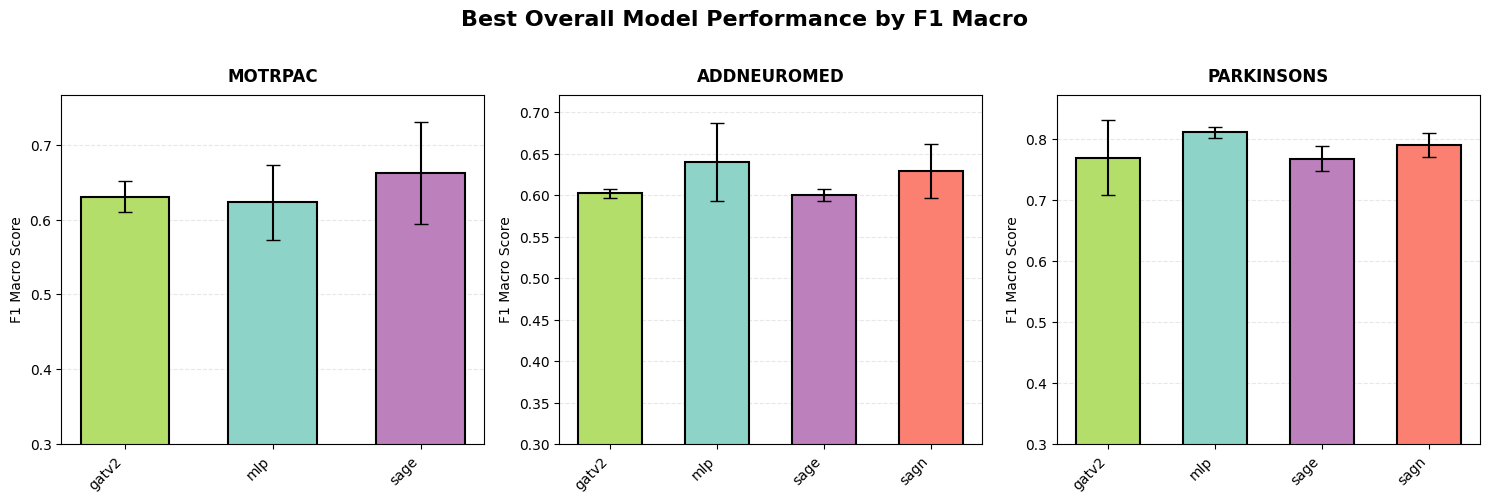


Best Performance by Model and Dataset:

gatv2:
  motrpac: 0.6307 ± 0.0207
  addneuromed: 0.6020 ± 0.0059
  parkinsons: 0.7692 ± 0.0611

mlp:
  motrpac: 0.6228 ± 0.0496
  addneuromed: 0.6397 ± 0.0467
  parkinsons: 0.8104 ± 0.0095

sage:
  motrpac: 0.6622 ± 0.0679
  addneuromed: 0.5998 ± 0.0074
  parkinsons: 0.7675 ± 0.0205

sagn:
  motrpac: No data
  addneuromed: 0.6289 ± 0.0321
  parkinsons: 0.7901 ± 0.0192


In [13]:
# ------------------------------------------------------------------
# Plot: Best Overall Model Performance by F1 Macro
# ------------------------------------------------------------------
# Set font to CMU Serif
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif']

# Read from aggregated_results.csv and filter for each dataset and model
# Rows: Models (from model.model_name)
# Columns: Datasets
# Each subplot: Best performance for that model-dataset combination
metric_col = "summary.best_test/f1_macro"
metric_std_col = f"{metric_col}_std"
data_name_col = "dataset.loader.parameters.data_name"
method_col = "model.model_name"

# Helper function to decode serialized values
def _decode_val(x):
    """Decode serialized values like "__val__:'sagn'" -> "sagn"."""
    if isinstance(x, str):
        if x == "__NaN__":
            return np.nan
        if x.startswith("__val__:"):
            inner = x[len("__val__:"):]
            # Strip simple quotes if present
            if inner.startswith("'") and inner.endswith("'"):
                return inner[1:-1]
            # Try to literal-eval numbers / booleans
            try:
                return ast.literal_eval(inner)
            except Exception:
                return inner
    return x

# Load aggregated data
df_plot = aggregated_df.copy()

# Decode serialized values for the grouping columns
for col in [data_name_col, method_col]:
    if col in df_plot.columns:
        df_plot[col] = df_plot[col].apply(_decode_val)

# Ensure metrics are numeric
df_plot[metric_col] = pd.to_numeric(df_plot[metric_col], errors="coerce")
df_plot[metric_std_col] = pd.to_numeric(df_plot[metric_std_col], errors="coerce")

# Filter to valid data and the three datasets
df_plot = df_plot.dropna(subset=[data_name_col, method_col, metric_col])
df_plot = df_plot[df_plot[data_name_col].isin(["motrpac", "addneuromed", "parkinsons"])]

# Get all unique models and datasets
all_models = sorted(df_plot[method_col].dropna().unique().tolist())
datasets = ["motrpac", "addneuromed", "parkinsons"]  # Keep consistent order

# For each model-dataset combination, find the best performance
plot_data = {}
for model in all_models:
    plot_data[model] = {}
    for dataset in datasets:
        # Filter for this model-dataset combination
        subset = df_plot[
            (df_plot[method_col] == model) &
            (df_plot[data_name_col] == dataset)
        ]
        
        if len(subset) > 0:
            # Find the best performance for this combination
            best_idx = subset[metric_col].idxmax()
            plot_data[model][dataset] = {
                'mean': subset.loc[best_idx, metric_col],
                'std': subset.loc[best_idx, metric_std_col]
            }
        else:
            plot_data[model][dataset] = {'mean': np.nan, 'std': np.nan}

# Sort models by best overall performance for color assignment
# Create shared color mapping that will be reused across all plots
model_best_perf = {}
for model in all_models:
    best_vals = []
    for dataset in datasets:
        if dataset in plot_data[model] and not np.isnan(plot_data[model][dataset]['mean']):
            best_vals.append(plot_data[model][dataset]['mean'])
    model_best_perf[model] = max(best_vals) if best_vals else 0

sorted_models = sorted(all_models, key=lambda m: model_best_perf.get(m, 0), reverse=True)
# Create shared color mapping - this will be reused in all subsequent plots
shared_model_colors_dict = {model: plt.cm.Set3(i / len(sorted_models)) for i, model in enumerate(sorted_models)}
method_colors_dict = shared_model_colors_dict  # Keep for backward compatibility

# Create the subplot grid: 1 row x 3 columns (datasets), all models together
fig, axes = plt.subplots(1, len(datasets), figsize=(15, 5))
fig.suptitle('Best Overall Model Performance by F1 Macro', 
             fontsize=16, fontweight='bold', y=0.995)

# If only one dataset, axes will be 1D, so make it 2D
if len(datasets) == 1:
    axes = axes.reshape(1, -1)
else:
    axes = axes.reshape(1, -1)

# Plot each subplot (one per dataset)
for j, dataset in enumerate(datasets):
    ax = axes[0, j]
    
    # Collect data for all models for this dataset
    means = []
    stds = []
    labels = []
    colors = []
    
    for model in all_models:
        data = plot_data[model][dataset]
        mean_val = data['mean']
        std_val = data['std']
        
        if not np.isnan(mean_val):
            means.append(mean_val)
            stds.append(std_val)
            labels.append(model)
            colors.append(method_colors_dict[model])
    
    # Create positions for bars
    if len(means) > 0:
        x_positions = np.arange(len(means))
        bar_width = 0.6  # Fixed bar width
        
        # Create grouped bars for all models
        bars = ax.bar(
            x_positions,
            means,
            yerr=stds,
            width=bar_width,
            capsize=5,
            color=colors,
            edgecolor='black',
            linewidth=1.5
        )
        
        # Customize subplot
        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels, rotation=45, ha='right')
    else:
        # No data for this dataset
        ax.set_xticks([])
    
    ax.set_ylabel('F1 Macro Score', fontsize=10)
    ax.set_title(dataset.upper(), fontsize=12, fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_ylim(0.3, None)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Print the values for reference
print("\nBest Performance by Model and Dataset:")
print("=" * 80)
for model in all_models:
    print(f"\n{model}:")
    for dataset in datasets:
        data = plot_data[model][dataset]
        if not np.isnan(data['mean']):
            print(f"  {dataset}: {data['mean']:.4f} ± {data['std']:.4f}")
        else:
            print(f"  {dataset}: No data")


findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the f

findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the f

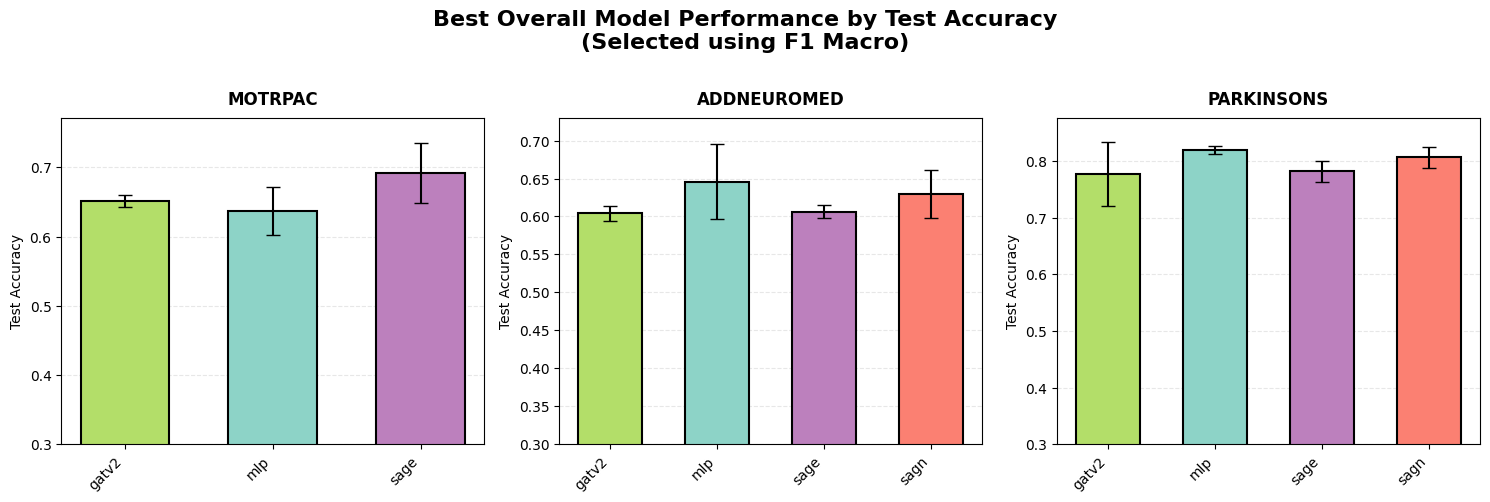


Best Performance by Model and Dataset (Test Accuracy, selected by F1 Macro):

gatv2:
  motrpac: 0.6517 ± 0.0086
  addneuromed: 0.6042 ± 0.0098
  parkinsons: 0.7778 ± 0.0566

mlp:
  motrpac: 0.6368 ± 0.0345
  addneuromed: 0.6458 ± 0.0491
  parkinsons: 0.8189 ± 0.0071

sage:
  motrpac: 0.6915 ± 0.0431
  addneuromed: 0.6065 ± 0.0080
  parkinsons: 0.7819 ± 0.0189

sagn:
  motrpac: No data
  addneuromed: 0.6296 ± 0.0321
  parkinsons: 0.8066 ± 0.0189


In [14]:
# ------------------------------------------------------------------
# Plot: Best Overall Model Performance by Test Accuracy
# (Selected using F1 Macro, plotted using Accuracy)
# ------------------------------------------------------------------
# Set font to CMU Serif
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif']

# Read from aggregated_results.csv and filter for each dataset and model
# Rows: Models (from model.model_name)
# Columns: Datasets
# Each subplot: Best performance for that model-dataset combination
# Use F1 Macro to select best runs, but plot Accuracy
selection_metric_col = "summary.best_test/f1_macro"  # Use this to select best runs
plot_metric_col = "summary.best_test/accuracy"  # Plot this metric
plot_metric_std_col = f"{plot_metric_col}_std"
data_name_col = "dataset.loader.parameters.data_name"
method_col = "model.model_name"

# Helper function to decode serialized values
def _decode_val(x):
    """Decode serialized values like "__val__:'sagn'" -> "sagn"."""
    if isinstance(x, str):
        if x == "__NaN__":
            return np.nan
        if x.startswith("__val__:"):
            inner = x[len("__val__:"):]
            # Strip simple quotes if present
            if inner.startswith("'") and inner.endswith("'"):
                return inner[1:-1]
            # Try to literal-eval numbers / booleans
            try:
                return ast.literal_eval(inner)
            except Exception:
                return inner
    return x

# Load aggregated data
df_plot = aggregated_df.copy()

# Decode serialized values for the grouping columns
for col in [data_name_col, method_col]:
    if col in df_plot.columns:
        df_plot[col] = df_plot[col].apply(_decode_val)

# Ensure metrics are numeric
df_plot[selection_metric_col] = pd.to_numeric(df_plot[selection_metric_col], errors="coerce")
df_plot[plot_metric_col] = pd.to_numeric(df_plot[plot_metric_col], errors="coerce")
df_plot[plot_metric_std_col] = pd.to_numeric(df_plot[plot_metric_std_col], errors="coerce")

# Filter to valid data and the three datasets
df_plot = df_plot.dropna(subset=[data_name_col, method_col, selection_metric_col])
df_plot = df_plot[df_plot[data_name_col].isin(["motrpac", "addneuromed", "parkinsons"])]

# Get all unique models and datasets
all_models = sorted(df_plot[method_col].dropna().unique().tolist())
datasets = ["motrpac", "addneuromed", "parkinsons"]  # Keep consistent order

# For each model-dataset combination, find the best performance using F1 Macro
# Then extract the Accuracy values for those best runs
plot_data = {}
for model in all_models:
    plot_data[model] = {}
    for dataset in datasets:
        # Filter for this model-dataset combination
        subset = df_plot[
            (df_plot[method_col] == model) &
            (df_plot[data_name_col] == dataset)
        ]
        
        if len(subset) > 0:
            # Find the best performance using F1 Macro for selection
            best_idx = subset[selection_metric_col].idxmax()
            # Extract Accuracy values from the same best run
            plot_data[model][dataset] = {
                'mean': subset.loc[best_idx, plot_metric_col],
                'std': subset.loc[best_idx, plot_metric_std_col]
            }
        else:
            plot_data[model][dataset] = {'mean': np.nan, 'std': np.nan}

# Use shared color mapping from Cell 4 (based on F1 macro performance)
# This ensures consistent colors across all plots
if 'shared_model_colors_dict' in globals():
    method_colors_dict = shared_model_colors_dict.copy()
    # Add any missing models with new colors if needed
    for model in all_models:
        if model not in method_colors_dict:
            # Get the maximum index used so far
            max_idx = len(method_colors_dict)
            method_colors_dict[model] = plt.cm.Set3(max_idx / max(len(all_models), 1))
else:
    # Fallback: create color mapping if Cell 4 hasn't been run yet
    # Sort models by best overall performance (using accuracy as fallback)
    model_best_perf = {}
    for model in all_models:
        best_vals = []
        for dataset in datasets:
            if dataset in plot_data[model] and not np.isnan(plot_data[model][dataset]['mean']):
                best_vals.append(plot_data[model][dataset]['mean'])
        model_best_perf[model] = max(best_vals) if best_vals else 0
    
    sorted_models = sorted(all_models, key=lambda m: model_best_perf.get(m, 0), reverse=True)
    method_colors_dict = {model: plt.cm.Set3(i / len(sorted_models)) for i, model in enumerate(sorted_models)}
    shared_model_colors_dict = method_colors_dict.copy()

# Create the subplot grid: 1 row x 3 columns (datasets), all models together
fig, axes = plt.subplots(1, len(datasets), figsize=(15, 5))
fig.suptitle('Best Overall Model Performance by Test Accuracy\n(Selected using F1 Macro)', 
             fontsize=16, fontweight='bold', y=0.995)

# If only one dataset, axes will be 1D, so make it 2D
if len(datasets) == 1:
    axes = axes.reshape(1, -1)
else:
    axes = axes.reshape(1, -1)

# Plot each subplot (one per dataset)
for j, dataset in enumerate(datasets):
    ax = axes[0, j]
    
    # Collect data for all models for this dataset
    means = []
    stds = []
    labels = []
    colors = []
    
    for model in all_models:
        data = plot_data[model][dataset]
        mean_val = data['mean']
        std_val = data['std']
        
        if not np.isnan(mean_val):
            means.append(mean_val)
            stds.append(std_val)
            labels.append(model)
            colors.append(method_colors_dict[model])
    
    # Create positions for bars
    if len(means) > 0:
        x_positions = np.arange(len(means))
        bar_width = 0.6  # Fixed bar width
        
        # Create grouped bars for all models
        bars = ax.bar(
            x_positions,
            means,
            yerr=stds,
            width=bar_width,
            capsize=5,
            color=colors,
            edgecolor='black',
            linewidth=1.5
        )
        
        # Customize subplot
        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels, rotation=45, ha='right')
    else:
        # No data for this dataset
        ax.set_xticks([])
    
    ax.set_ylabel('Test Accuracy', fontsize=10)
    ax.set_title(dataset.upper(), fontsize=12, fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_ylim(0.3, None)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Print the values for reference
print("\nBest Performance by Model and Dataset (Test Accuracy, selected by F1 Macro):")
print("=" * 80)
for model in all_models:
    print(f"\n{model}:")
    for dataset in datasets:
        data = plot_data[model][dataset]
        if not np.isnan(data['mean']):
            print(f"  {dataset}: {data['mean']:.4f} ± {data['std']:.4f}")
        else:
            print(f"  {dataset}: No data")


findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Generic family 'serif' not found because none of the f

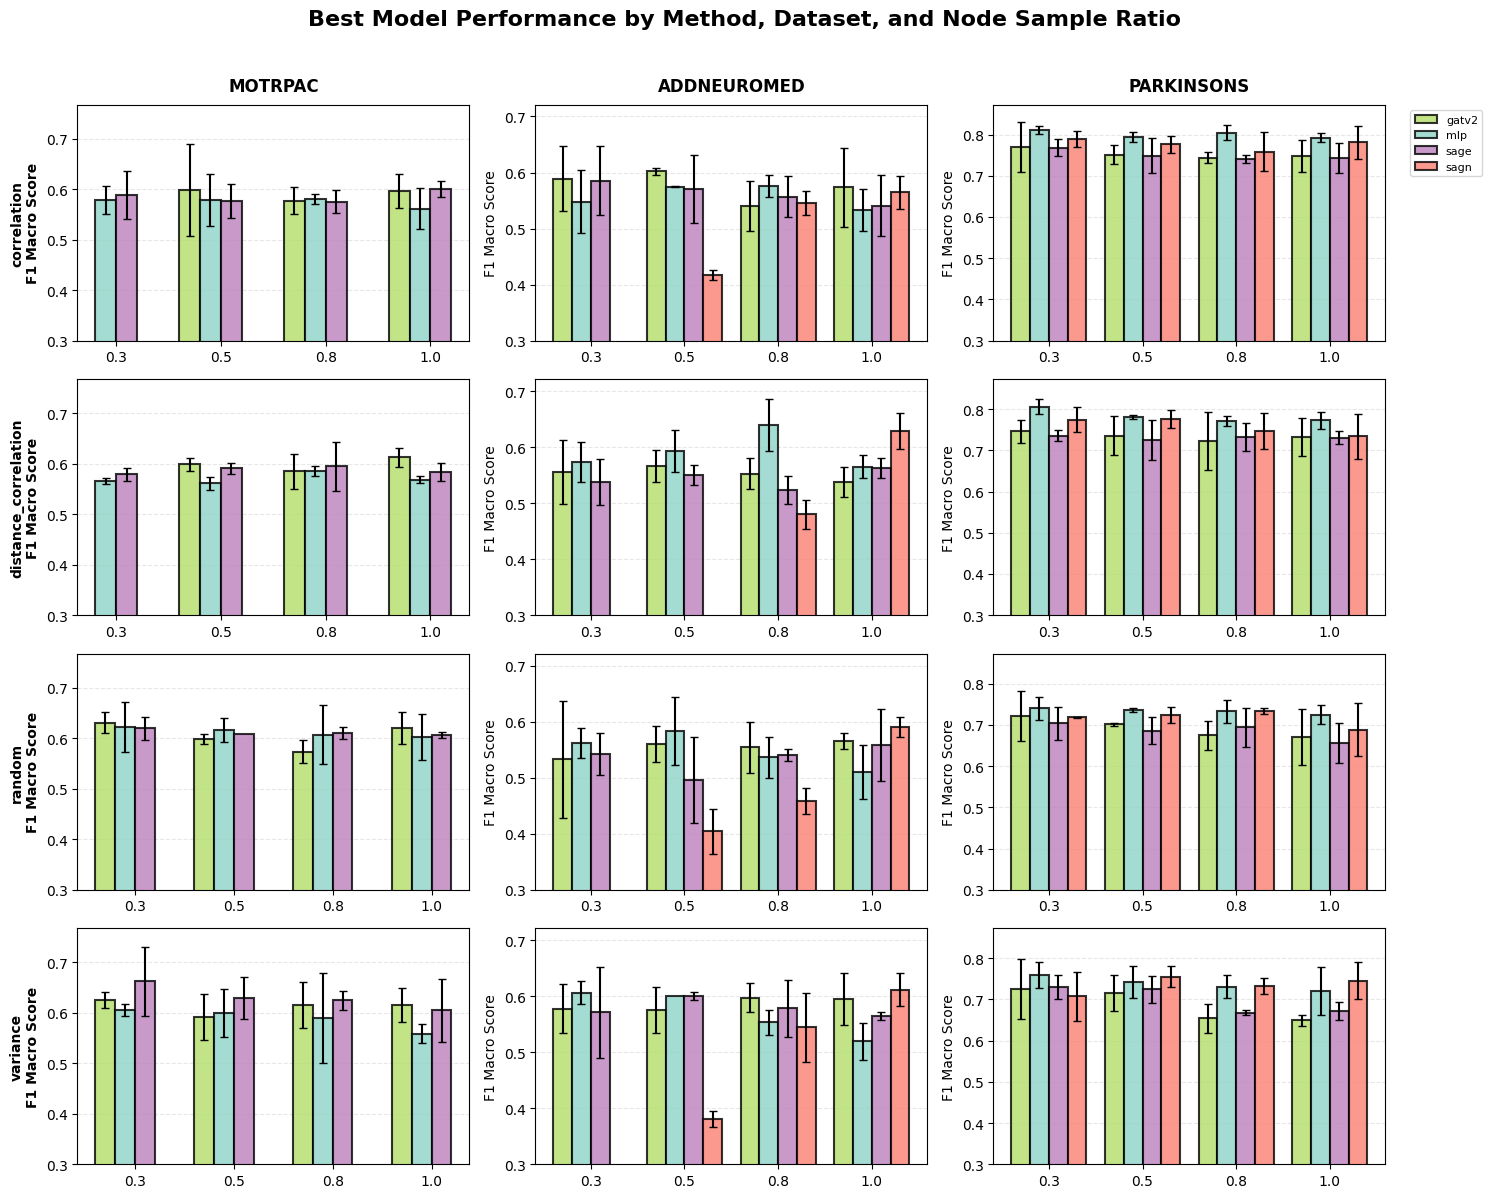


Data Summary:

correlation:
  motrpac:
    0.3:
      gatv2: No data
      mlp: 0.5783 ± 0.0276
      sage: 0.5879 ± 0.0469
      sagn: No data
    0.5:
      gatv2: 0.5978 ± 0.0910
      mlp: 0.5791 ± 0.0515
      sage: 0.5765 ± 0.0329
      sagn: No data
    0.8:
      gatv2: 0.5768 ± 0.0271
      mlp: 0.5800 ± 0.0097
      sage: 0.5750 ± 0.0223
      sagn: No data
    1.0:
      gatv2: 0.5955 ± 0.0338
      mlp: 0.5607 ± 0.0407
      sage: 0.5996 ± 0.0159
      sagn: No data
  addneuromed:
    0.3:
      gatv2: 0.5893 ± 0.0580
      mlp: 0.5481 ± 0.0564
      sage: 0.5857 ± 0.0619
      sagn: No data
    0.5:
      gatv2: 0.6020 ± 0.0059
      mlp: 0.5751 ± 0.0002
      sage: 0.5705 ± 0.0604
      sagn: 0.4171 ± 0.0091
    0.8:
      gatv2: 0.5399 ± 0.0449
      mlp: 0.5758 ± 0.0194
      sage: 0.5569 ± 0.0362
      sagn: 0.5461 ± 0.0218
    1.0:
      gatv2: 0.5735 ± 0.0704
      mlp: 0.5329 ± 0.0369
      sage: 0.5412 ± 0.0538
      sagn: 0.5644 ± 0.0290
  parkinsons:
    0.3:
  

In [15]:
# ------------------------------------------------------------------
# Plot: Best Model Performance by Method, Dataset, and Node Sample Ratio
# ------------------------------------------------------------------
# Set font to CMU Serif (if not already set)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif']

# Extract data from aggregated_df directly
# Rows: methods (from dataset.loader.parameters.method)
# Columns: datasets
# Each subplot: For each node_sample_ratio, show bars for all models
metric_col = "summary.best_test/f1_macro"
metric_std_col = f"{metric_col}_std"
data_name_col = "dataset.loader.parameters.data_name"
method_col = "dataset.loader.parameters.method"  # Rows: sampling methods
model_col = "model.model_name"  # Bars: models
node_sample_ratio_col = "dataset.loader.parameters.node_sample_ratio"

# Helper function to decode serialized values
def _decode_val(x):
    """Decode serialized values like "__val__:'sagn'" -> "sagn"."""
    if isinstance(x, str):
        if x == "__NaN__":
            return np.nan
        if x.startswith("__val__:"):
            inner = x[len("__val__:"):]
            # Strip simple quotes if present
            if inner.startswith("'") and inner.endswith("'"):
                return inner[1:-1]
            # Try to literal-eval numbers / booleans
            try:
                return ast.literal_eval(inner)
            except Exception:
                return inner
    return x

# Load aggregated data
df_plot2 = aggregated_df.copy()

# Decode serialized values for the grouping columns
for col in [data_name_col, method_col, model_col, node_sample_ratio_col]:
    if col in df_plot2.columns:
        df_plot2[col] = df_plot2[col].apply(_decode_val)

# Ensure metrics are numeric
df_plot2[metric_col] = pd.to_numeric(df_plot2[metric_col], errors="coerce")
df_plot2[metric_std_col] = pd.to_numeric(df_plot2[metric_std_col], errors="coerce")

# Filter to valid data and the three datasets
df_plot2 = df_plot2.dropna(subset=[data_name_col, method_col, model_col, node_sample_ratio_col, metric_col])
df_plot2 = df_plot2[df_plot2[data_name_col].isin(["motrpac", "addneuromed", "parkinsons"])]

# Get all unique methods (rows), models (bars), datasets (columns), and ratios (groups)
all_methods = sorted(df_plot2[method_col].dropna().unique().tolist())
all_models = sorted(df_plot2[model_col].dropna().unique().tolist())
datasets = ["motrpac", "addneuromed", "parkinsons"]  # Keep consistent order
all_ratios = sorted(df_plot2[node_sample_ratio_col].dropna().unique().tolist())

# Use the shared color mapping from Cell 4 for models (bars)
# This ensures consistent colors across all plots
if 'shared_model_colors_dict' in globals():
    # Use existing shared color mapping from Cell 4
    model_colors = shared_model_colors_dict.copy()
    # Add any missing models with new colors if needed
    for model in all_models:
        if model not in model_colors:
            # Get the maximum index used so far
            max_idx = len(model_colors)
            model_colors[model] = plt.cm.Set3(max_idx / max(len(all_models), 1))
elif 'method_colors_dict' in globals():
    # Fallback to method_colors_dict if shared_model_colors_dict doesn't exist
    model_colors = method_colors_dict.copy()
    # Add any missing models with new colors
    for model in all_models:
        if model not in model_colors:
            max_idx = len(model_colors)
            model_colors[model] = plt.cm.Set3(max_idx / max(len(all_models), 1))
else:
    # Create color mapping using the same logic as first plot
    # First, compute best performance for each model to get the same ordering
    model_best_perf = {}
    for model in all_models:
        model_data = df_plot2[df_plot2[model_col] == model]
        if len(model_data) > 0:
            model_best_perf[model] = model_data[metric_col].max()
        else:
            model_best_perf[model] = 0
    
    # Sort models by best performance (same as first plot)
    sorted_models = sorted(all_models, key=lambda m: model_best_perf.get(m, 0), reverse=True)
    model_colors = {model: plt.cm.Set3(i / len(sorted_models)) for i, model in enumerate(sorted_models)}
    # Store as shared for future use
    shared_model_colors_dict = model_colors.copy()

# Extract mean and std values for each method-dataset-ratio-model combination
# For each method-dataset-ratio-model, find the best performance
plot_data = {}
for method in all_methods:
    plot_data[method] = {}
    for dataset in datasets:
        plot_data[method][dataset] = {}
        for ratio in all_ratios:
            plot_data[method][dataset][ratio] = {}
            for model in all_models:
                # Filter for this method-dataset-ratio-model combination
                subset = df_plot2[
                    (df_plot2[method_col] == method) &
                    (df_plot2[data_name_col] == dataset) &
                    (df_plot2[node_sample_ratio_col] == ratio) &
                    (df_plot2[model_col] == model)
                ]
                
                if len(subset) > 0:
                    # Find the best performance for this combination
                    best_idx = subset[metric_col].idxmax()
                    plot_data[method][dataset][ratio][model] = {
                        'mean': subset.loc[best_idx, metric_col],
                        'std': subset.loc[best_idx, metric_std_col]
                    }
                else:
                    plot_data[method][dataset][ratio][model] = {'mean': np.nan, 'std': np.nan}

# Create the subplot grid: 4 rows (methods) x 3 columns (datasets)
fig, axes = plt.subplots(len(all_methods), len(datasets), figsize=(15, 12))
fig.suptitle('Best Model Performance by Method, Dataset, and Node Sample Ratio', 
             fontsize=16, fontweight='bold', y=0.995)

# If only one method, axes will be 1D, so make it 2D
if len(all_methods) == 1:
    axes = axes.reshape(1, -1)
if len(datasets) == 1:
    axes = axes.reshape(-1, 1)

# First, calculate the maximum y-value for each dataset (column) across all methods
# This ensures all subplots in the same column have the same y-axis scale
dataset_max_vals = {}
for j, dataset in enumerate(datasets):
    max_val = 0.3  # Start with minimum
    for i, method in enumerate(all_methods):
        method_data = plot_data[method][dataset]
        for ratio in all_ratios:
            for model in all_models:
                if model in method_data[ratio]:
                    mean_val = method_data[ratio][model]['mean']
                    std_val = method_data[ratio][model]['std']
                    if not np.isnan(mean_val):
                        # Consider mean + std for error bars
                        max_val = max(max_val, mean_val + (std_val if not np.isnan(std_val) else 0))
    # Add a small padding (5%) to the max value
    dataset_max_vals[dataset] = max_val * 1.05

# Plot each subplot
# Each subplot shows: for each node_sample_ratio, bars for all models
bar_width = 0.8 / len(all_models)  # Width of each bar group
group_width = 0.8  # Total width of each group

for i, method in enumerate(all_methods):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]
        
        # Get data for this method-dataset combination
        method_data = plot_data[method][dataset]
        
        # Create positions for grouped bars
        x_groups = np.arange(len(all_ratios))  # Positions for each ratio group
        x_positions = {}  # Store x positions for each model within each group
        
        # Calculate offset for each model to center the group
        for model_idx, model in enumerate(all_models):
            offset = (model_idx - (len(all_models) - 1) / 2) * bar_width
            x_positions[model] = x_groups + offset
        
        # Plot bars for each model, grouped by ratio
        for model in all_models:
            means = []
            stds = []
            for ratio in all_ratios:
                if model in method_data[ratio]:
                    means.append(method_data[ratio][model]['mean'])
                    stds.append(method_data[ratio][model]['std'])
                else:
                    means.append(np.nan)
                    stds.append(np.nan)
            
            bars = ax.bar(
                x_positions[model],
                means,
                yerr=stds,
                width=bar_width,
                capsize=3,
                label=model,
                color=model_colors[model],
                edgecolor='black',
                linewidth=1.5,
                alpha=0.8
            )
        
        # Customize subplot
        ax.set_xticks(x_groups)
        ax.set_xticklabels(all_ratios, rotation=0)
        ax.set_ylabel('F1 Macro Score', fontsize=10)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        # Set y-axis limits: same max for all subplots in the same column (dataset)
        ax.set_ylim(0.3, dataset_max_vals[dataset])
        
        # Set title: method name on left, dataset name on top
        if i == 0:  # Top row: dataset names
            ax.set_title(dataset.upper(), fontsize=12, fontweight='bold', pad=10)
        if j == 0:  # Left column: method names
            ax.set_ylabel(f'{method}\nF1 Macro Score', fontsize=10, fontweight='bold')
        
        # Add legend only to the top-right subplot
        if i == 0 and j == len(datasets) - 1:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Print summary
print("\nData Summary:")
print("=" * 80)
for method in all_methods:
    print(f"\n{method}:")
    for dataset in datasets:
        print(f"  {dataset}:")
        for ratio in all_ratios:
            print(f"    {ratio}:")
            for model in all_models:
                if model in plot_data[method][dataset][ratio]:
                    data = plot_data[method][dataset][ratio][model]
                    if not np.isnan(data['mean']):
                        print(f"      {model}: {data['mean']:.4f} ± {data['std']:.4f}")
                    else:
                        print(f"      {model}: No data")
                else:
                    print(f"      {model}: No data")
